In [85]:
import pandas as pd

In [86]:
products_cl_csv = "C:\\Users\\pakan\\OneDrive\\WBS_DATA SCIENCE BOOTCAMP\\DATA SCIENCE Main Course\\PANDAS\\Case study - Eniac Discount Strategy data files\\csv files\\products_cl.csv"
products_df = pd.read_csv(products_cl_csv)

In [87]:
product_category_df = products_df.copy()

In [88]:
product_category_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9992 entries, 0 to 9991
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       9992 non-null   str    
 1   name      9992 non-null   str    
 2   desc      9992 non-null   str    
 3   price     9992 non-null   float64
 4   in_stock  9992 non-null   int64  
 5   type      9946 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 468.5 KB


In [89]:
pd.set_option('display.max_rows', 1000)
pd.set_option("display.max_colwidth", 100)

In [90]:
product_category_df.head()

,sku,name,desc,price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pro (2006/07/08).,34.99,1,1364


In [91]:
##filling a new column called category with no item in it
product_category_df["category"] = ""
product_category_df.head()

,sku,name,desc,price,in_stock,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pro (2006/07/08).,34.99,1,1364,


We can find all the products with certain words in their `description` using `.loc[]` and `.str.contains()`. Here we'll look at all the items that have the word `keyboard` in their description.

In [92]:
product_category_df.loc[product_category_df["desc"].str.contains("keyboard", case=False)]

,sku,name,desc,price,in_stock,type,category
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,
15,MOS0021,Clearguard Moshi MacBook Pro and Air,Keyboard Protector MacBook Pro 13-inch Retina 15 inches 17 inches 13 inches 15 inches and 13-inc...,24.95,0,13835403,
24,APP0277,Apple Wireless Keyboard Keyboard (OEM) Mac,Ultrathin keyboard Apple Bluetooth Spanish (unboxed).,79.00,0,13855401,
64,HGD0012,Henge Docks Click keyboard support iMac,Base to hold the Apple Magic TrackPad and Wireless Keyboard Dock,29.00,0,8696,
365,LOG0084,Logitech Ultrathin Keyboard Cover Keyboard Cover iPad Mini / Retina Black,Ultrathin cover and cover with Bluetooth keyboard for iPad mini Spanish 2 and 3,89.99,0,12575403,
575,MOS0105,Moshi Clearguard CS Keyboard Protector,Transparent protective keyboard.,19.99,0,13835403,
1372,LOG0144,Logitech Keys-To-Go iPad Keyboard Black,Bluetooth wireless mechanical keyboard in Spanish for iPad iPhone and Apple TV.,71.99,0,54025401,
1374,LOG0156,Logitech iPad Keys-To-Go Keyboard Red,Bluetooth wireless mechanical keyboard in Spanish for iPad iPhone and Apple TV.,71.99,0,54025401,
1397,LOG0148,Logitech Type + Keyboard Folio iPad Air 2 Black,Keyboard Case for iPad Air 2.,119.00,0,12575403,
1436,KEN0200,Kensington KeyFolio Plus X2 Thin Case with backlit keyboard iPad Air 2 Black,Cover with Spanish backlit keyboard for iPad Air 2,109.99,0,12575403,


In [93]:
#Change the category bane to Keyboard
product_category_df.loc[product_category_df["desc"].str.contains("keyboard", case=False), "category"] = "keyboard"

In [94]:
#look for keyboard as a new category
product_category_df["category"].value_counts()

category
            9903
keyboard      89
Name: count, dtype: int64

In [95]:
#2.&nbsp; Category creation using regex
#We can also use a product's `name` to select products for our categories.
product_category_df.loc[product_category_df["name"].str.contains("apple iphone", case=False)]

,sku,name,desc,price,in_stock,type,category
35,APP0308,AV Cable Adapter Apple iPhone iPad and iPod white,IPhone iPad iPod adapter and AV cable.,45.00,0,1230,
214,REP0100,Color change to White Apple iPhone 4,It is including parts and labor..,94.21,0,"1,44E+11",
215,REP0052,Color change to White Apple iPhone 4,It is including parts and labor..,94.21,0,"1,44E+11",
579,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559.00,0,NaN,
956,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639.00,0,NaN,
961,APP0829,Apple iPhone 6 Plus 16GB Silver,New iPhone 6 Plus 16G Free (MGA92QL / A).,749.00,0,NaN,
962,APP0822,Apple iPhone 6 16GB Space Gray,New iPhone 6 16GB Free (MG472QL / A).,639.00,0,NaN,
963,APP0825,Apple iPhone 6 64GB Space Gray,New iPhone 6 64GB Free (MG4F2QL / A).,749.00,0,NaN,
964,APP0826,Apple iPhone 6 64GB Silver,New iPhone 6 64GB Free (MG4H2QL / A).,749.00,0,NaN,
965,APP0828,Apple iPhone 6 Plus 16GB Space Gray,New 16GB iPhone 6 Plus Free (MGA82QL / A).,749.00,0,NaN,


In [96]:
#Looks like we get a lot of accessories included in this search. We can refine this using a little regex. Here, we will add `.{0,7}` at the beginning of the search: this means we will find all `apple iphone`s that have 7 or less characters preceding the term "apple iphone" - if there's 8 characters preceding the search term, it won't be found. This should help refine our search by using the nomenclature of the DataFrame to our advantage.

#If you feel unsure about regex, please use [regex101](https://regex101.com/). It's really useful for checking your code, and parts of other people's code that you're unsure about.
product_category_df.loc[product_category_df["name"].str.contains("^.{0,7}apple iphone", case=False)]

,sku,name,desc,price,in_stock,type,category
579,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559.00,0,NaN,
956,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639.00,0,NaN,
961,APP0829,Apple iPhone 6 Plus 16GB Silver,New iPhone 6 Plus 16G Free (MGA92QL / A).,749.00,0,NaN,
962,APP0822,Apple iPhone 6 16GB Space Gray,New iPhone 6 16GB Free (MG472QL / A).,639.00,0,NaN,
963,APP0825,Apple iPhone 6 64GB Space Gray,New iPhone 6 64GB Free (MG4F2QL / A).,749.00,0,NaN,
964,APP0826,Apple iPhone 6 64GB Silver,New iPhone 6 64GB Free (MG4H2QL / A).,749.00,0,NaN,
965,APP0828,Apple iPhone 6 Plus 16GB Space Gray,New 16GB iPhone 6 Plus Free (MGA82QL / A).,749.00,0,NaN,
966,APP0832,Apple iPhone 6 Plus Case White,Ultrathin silicone case and microfiber premium.,39.00,0,11865403,
967,APP0834,Apple iPhone 6 Plus Case Blue,Ultrathin silicone case and microfiber premium.,39.00,0,11865403,
968,APP0835,Apple iPhone 6 Plus Case Rosa,Ultrathin silicone case and microfiber premium.,39.00,0,11865403,


In [97]:
#Now we can use the same trick as before to set the category - selecting the `category` column and setting it to the string of our choice.
product_category_df.loc[product_category_df["name"].str.contains("^.{0,7}apple iphone", case=False), "category"] = "smartphone"
product_category_df["category"].value_counts()

category
              9634
smartphone     269
keyboard        89
Name: count, dtype: int64

In [98]:
## 3.&nbsp; One product with multiple categories
#A product may fit into multiple categories. To help us create multiple categories for one product, we will use the python addition assignment `+=`. The addition assignment is a shorthand way to add something (number, string, etc...) to a variable without changing the variable name.
#Let's have a look at a couple of examples.

In [99]:
a = 10
a = a + 5
a

15

In [100]:
a = 10
a += 5
a

15

In [101]:
b = "Tyrannosaurus"
b = b + " rex"
b

'Tyrannosaurus rex'

In [102]:
b = "Anderson"
b = b + " andy"
b

'Anderson andy'

In [103]:
b = "Tyrannosaurus"
b += " rex"
b

'Tyrannosaurus rex'

In [104]:
#Now let's look at how this can help us in our category creation.
#First, we'll reset all the values in the category column to an empty string `""`.
product_category_df["category"] = ""

In [105]:
product_category_df.loc[product_category_df["desc"].str.contains("keyboard", case=False), "category"] += ", keyboard"
product_category_df.loc[product_category_df["name"].str.contains("^.{0,7}apple iphone", case=False), "category"] += ", smartphone"
product_category_df.loc[product_category_df["name"].str.contains("^.{0,7}apple ipod", case=False), "category"] += ", ipod"
product_category_df.loc[product_category_df["name"].str.contains("^.{0,7}apple ipad|tablet", case=False), "category"] += ", tablet"
product_category_df.loc[product_category_df["name"].str.contains("imac|mac mini|mac pro", case=False), "category"] += ", desktop"

In [106]:
product_category_df["category"].value_counts()

category
                       8362
, desktop               923
, tablet                307
, smartphone            269
, keyboard               83
, ipod                   42
, keyboard, tablet        4
, keyboard, desktop       2
Name: count, dtype: int64

# Challenge. Your categories
Now it's your turn. We'll reset the Dataframe so that no categories exist, and it's up to you to create the categories based on keywords in the name and description. Feel free to go wild and make as many categories as you like.
* Remember you can also use regex to refine your searches.
* Remember you can use the or operator `|` to search for multiple terms at once.
* Remember to tidy up any untidy strings at the end.

In [107]:
# resetting to original import
product_category_exx_df = products_df.copy()

In [108]:
product_category_exx_df["category"] = ""
product_category_exx_df.head()

,sku,name,desc,price,in_stock,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pro (2006/07/08).,34.99,1,1364,


In [109]:
product_category_exx_df.loc[product_category_exx_df["desc"].str.contains("Battery", case=False)]

,sku,name,desc,price,in_stock,type,category
25,MOP0011,Mophie Juice Pack Air Battery Case iPhone 4 / 4S black,Battery Case iPhone 4 / 4S rigid polymer.,69.99,0,"5,49E+11",
46,MOB0010,Additional Battery Pack Mobee Magic Bar,Pack extra battery Mobee Magic Bar.,29.99,0,12355400,
57,MOP0013,Mophie Juice Pack Air Battery Case iPhone 4 / 4S White,Case Battery (1500mAh) iPhone 4 / 4S polymer.,69.95,0,"5,49E+11",
156,NTE0017,"NewerTech NuPower Battery MacBook 13 ""white",133 inch MacBook battery (White Model).,119.99,1,10142,
157,NTE0018,"NewerTech NuPower Battery MacBook 13 ""Black",133 inch MacBook battery (Black Model).,119.99,1,10142,
158,NTE0039,"NewerTech NuPower battery PowerBook G4 15 """,Battery replacement PowerBook G4 15 inches.,99.99,0,13005399,
159,NTE0020,"NewerTech NuPower battery MacBook Pro 15 ""(Late 2008 - Early 2009)",Battery MacBook Pro 15-inch Unibody late 2008 and early 2009,119.99,1,10142,
160,NTE0021,"NewerTech NuPower Battery MacBook 13 ""Aluminum",battery MacBook 13-inch (Aluminum Model).,119.99,1,10142,
171,NTE0022,"NewerTech NuPower battery MacBook Pro 17 ""(2006-2008)",MacBook Pro 17 inch battery.,145.99,0,10142,
228,REP0080,repair battery cases (1st generation),Battery Repair Service includes parts and labor for iPad,69.99,0,"1,44E+11",


In [110]:
#product_category_exx_df.loc[product_category_exx_df["name"].str.contains("Battery", case=False)]

In [111]:
#product_category_df.loc[product_category_df["name"].str.contains("^.{0,7}apple iphone", case=False)]

In [112]:
product_category_exx_df.loc[product_category_exx_df["name"].str.contains("^.{0,5}Battery", case=False)]

,sku,name,desc,price,in_stock,type,category
209,REP0041,battery repair iPhone 4,Repair service including parts and labor for iPhone 4,29.99,0,"1,44E+11",
1846,IFX0023,Battery Kit complete iFixit iPhone 4 battery change,Battery replacement kit with tools for iPhone 4.,19.95,0,12645406,
1849,IFX0021,Battery Kit complete change iFixit iPhone 4S Battery,Battery replacement kit with tools for iPhone 4S.,19.95,1,12645406,
1850,IFX0022,Battery Kit complete iFixit iPhone 5 battery change,Battery replacement kit with tools for iPhone 5.,30.99,1,12645406,
1884,REP0239,battery repair iPhone 6,Repair service including parts and labor for iPhone 6,59.99,0,"1,44E+11",
2067,IFX0029,"Battery iFixit MacBook Air 13 ""End 2010/2011 / Med 2012",replacement battery for MacBook Air 13-inch Late 2010/2011 / Med 2012.,109.99,0,13005399,
2493,IFX0037,Battery Kit complete change iFixit iPhone 3GS battery,Battery replacement kit with tools for iPhone 3GS.,19.95,0,12645406,
3075,PUR0137,Pure Battery Bank 3000mAh Battery Case with iPhone 6 / 6S Black,Battery Case for iPhone 6 / 6S.,74.95,0,"5,49E+11",
4274,IFX0051,"Battery iFixit MacBook Air 11 ""Late 2010",Battery replacement Macbook 11 inches end 2010,96.99,1,13005399,
4481,IFX0059,"Battery iFixit MacBook Air 13 ""(Late 2010)",new battery for MacBook Air 13-inch Late 2010,99.95,0,13005399,


In [113]:
product_category_exx_df.loc[product_category_exx_df["name"].str.contains("Battery", case=False), "category"] = "Battery"
product_category_exx_df["category"].value_counts()

category
           9746
Battery     246
Name: count, dtype: int64

In [114]:
product_category_exx_df.loc[product_category_exx_df["name"].str.contains("Charger", case=False)]

,sku,name,desc,price,in_stock,type,category
13,APP0156,45W MagSafe charger Apple MacBook Air,Charger MacBook Air MagSafe 45 W (MC747Z / A).,89.00,0,13005399,
16,APP0206,"60W MagSafe charger Apple MacBook and MacBook Pro 13 """,Charger MacBook and 13 inch MacBook MagSafe 60 W (MC461Z / A).,89.00,1,13005399,
20,APP0247,"85W MagSafe charger Apple MacBook Pro 15 ""/ 17""",Charger MacBook Pro MagSafe 85 W (MC556Z / A).,89.00,1,13005399,
23,MOB0007,Mobee Magic Charger Charger Magic Mouse,Wireless Charger for Magic Mouse,49.99,0,12355400,
79,MOB0012,Mobee Magic Trackpad Charger Power Bar,Charger for Magic Trackpad.,29.49,0,13005399,
127,APP0408,Apple 45W MagSafe 2 charger MacBook Air,Charger MacBook Air MagSafe 2 of 45 W (MD592Z / A).,89.00,0,13005399,
128,APP0409,Apple 85W MagSafe 2 charger MacBook Pro Retina screen 15 '',MagSafe charger 2 of 85 W (MD506Z / A).,89.00,1,13005399,
263,APP0474,"Apple 60W MagSafe 2 charger MacBook Pro Retina Display 13 """,MagSafe charger 2 of 60 W (MD565Z / A).,89.00,0,13005399,
343,TWS0040,Twelve South PlugBug World Dual Charger iPhone and iPad MacBook,dual charger for MacBook MagSafe and USB for iPhone and iPad.,49.99,0,13005399,
626,APP0702,"60W MagSafe charger Apple MacBook and MacBook Pro 13 ""(OEM)",Charger 60W MagSafe unboxed for MacBook and MacBook Pro 13-inch,89.00,1,13005399,


In [115]:
#product_category_exx_df.loc[product_category_exx_df["name"].str.contains("Charger", case=False), "category"] = "Charger"

In [116]:
#product_category_exx_df.loc[product_category_exx_df["name"].str.contains("^.{0,5}Battery", case=False), "category"] = "Charger"
#product_category_exx_df["category"].value_counts()

In [117]:
product_category_df["category"] = ""

In [118]:
product_category_exx_df.loc[product_category_exx_df["desc"].str.contains("Charger", case=False), "category"] += ", Charger"

product_category_exx_df.loc[product_category_exx_df["name"].str.contains("^.{0,7} Apple I Pad", case=False), "category"] += ", I Pad"

product_category_exx_df.loc[product_category_exx_df["name"].str.contains("^.{0,7} Apple MacBook", case=False), "category"] += ", MackBook"

product_category_exx_df.loc[product_category_exx_df["name"].str.contains("^.{0,7} apple ipad|tablet", case=False), "category"] += ", tablet"

product_category_exx_df.loc[product_category_exx_df["name"].str.contains("imac|mac mini|mac pro", case=False), "category"] += ", desktop"


In [119]:
product_category_exx_df["category"].value_counts()

category
                       8612
, desktop               925
Battery                 238
, Charger                92
, tablet                 79
, MackBook               37
Battery, Charger          8
, Charger, MackBook       1
Name: count, dtype: int64

In [120]:
# resetting to original import
product_category_ex_df = products_df.copy()

In [121]:

# 1. Initialize the category column
product_category_ex_df ['category'] = ''

#iphone_mask = product_category_ex_df ["name"].str.contains("^.{0,7}apple iphone", case=False, na=False)
#case_mask =product_category_ex_df ["name"].str.contains("case|cover|silicone|leather", case=False, na=False)
#product_category_ex_df .loc[iphone_mask & ~case_mask, "category"] = "Smartphone"
#product_category_ex_df.loc[case_mask, "category"] = "Protection"

# 4. Categorize Memory
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("RAM|Memory|GB", case=False, na=False), "category"] += "Memory"

# 5. Categorize Cables & Adapters
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Cable|Adapter|HDMI", case=False, na=False), "category"] = "Cables & Adapters"

# 6. Categorize Power
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Charger|MagSafe", case=False, na=False), "category"] = "Power"

# 7. Categorize Audio
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Headset|Headphone|Audio", case=False, na=False), "category"] = "Audio"

# 8. Categorize Peripherals
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Keyboard|Mouse|Keypad", case=False, na=False), "category"] = "Peripherals"

# 9. Categorize Stands & Docks
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Stand|Support|Dock", case=False, na=False), "category"] = "Stands & Docks"

# Check the results


In [122]:
product_category_ex_df['category'].value_counts()

category
                     5447
Memory               3108
Cables & Adapters     592
Stands & Docks        400
Audio                 215
Peripherals           136
Power                  94
Name: count, dtype: int64

product_category_ex_df.loc[product_category_ex_df["name"].str.contains("RAM|Memory|GB", case=False, na=False), "category"] = "Memory"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Cable|Adapter|HDMI", case=False, na=False), "category"] = "Cables & Adapters"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Charger|MagSafe", case=False, na=False), "category"] = "Power"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Headset|Headphone|Audio", case=False, na=False), "category"] = "Audio"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Keyboard|Mouse|Keypad", case=False, na=False), "category"] = "Peripherals"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Stand|Support|Dock", case=False, na=False), "category"] = "Stands & Docks"

In [123]:
# resetting to original import
product_category_ex_df = products_df.copy()


power_mask = product_category_ex_df["name"].str.contains("Charger|MagSafe|Battery|PowerBank", case=False, na=False)
product_category_ex_df.loc[power_mask, "category"] = "Power"
storage_keywords = "Hard drive|SSD|External box|Flash Drive|DataTraveler|WD Red|TB"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(storage_keywords, case=False, na=False), "category"] = "Storage"
repair_mask = product_category_ex_df["name"].str.contains("repair|service", case=False, na=False)
product_category_ex_df.loc[repair_mask, "category"] = "Repairs & Services"
tool_mask = product_category_ex_df["name"].str.contains("Kit|Tools|installation", case=False, na=False)
product_category_ex_df.loc[tool_mask, "category"] = "Tools & Kits"
cable_keywords = "Cable|Adapter|HDMI|Thunderbolt|FireWire|Lightning"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(cable_keywords, case=False, na=False), "category"] = "Cables & Adapters"
peri_keywords = "Keyboard|Mouse|Keypad|Pen|Switch"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(peri_keywords, case=False, na=False), "category"] = "Peripherals"
prot_keywords = "Case|Bumper|Cover|iGlaze|Armband|Clearguard"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(prot_keywords, case=False, na=False), "category"] = "Protection"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Stand|Support|Dock|Mount", case=False, na=False), "category"] = "Stands & Docks"

In [124]:

power_mask = product_category_ex_df["name"].str.contains("^.{0,7}Charger|MagSafe|Battery|PowerBank", case=False, na=False)
product_category_ex_df.loc[power_mask, "category"] += "Power"
storage_mask = "Hard drive|SSD|External box|Flash Drive|DataTraveler|WD Red|TB"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(storage_mask, case=False, na=False), "category"] += "Storage"
repair_mask = product_category_ex_df["name"].str.contains("repair|service", case=False, na=False)
product_category_ex_df.loc[repair_mask, "category"] += "Repairs & Services"
tool_mask = product_category_ex_df["name"].str.contains("Kit|Tools|installation", case=False, na=False)
product_category_ex_df.loc[tool_mask, "category"] += "Tools & Kits"
cable_mask = "Cable|Adapter|HDMI|Thunderbolt|FireWire|Lightning"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(cable_mask, case=False, na=False), "category"] += "Cables & Adapters"
peri_keywords = "Keyboard|Mouse|Keypad|Pen|Switch"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(peri_keywords, case=False, na=False), "category"] += "Peripherals"
protection_mask = "Case|Bumper|Cover|iGlaze|Armband|Clearguard"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(protection_mask, case=False, na=False), "category"] += "Protection"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Stand|Support|Dock|Mount", case=False, na=False), "category"] += "Stands & Docks"

KeyError: 'category'

In [ ]:
product_category_ex_df['category'].value_counts()

category
StorageStorage                                                          2086
ProtectionProtection                                                    1590
PeripheralsPeripherals                                                   675
Cables & AdaptersCables & Adapters                                       555
ProtectionPeripheralsProtection                                          253
Stands & DocksStands & Docks                                             234
PeripheralsStoragePeripherals                                            209
Tools & KitsStorageTools & Kits                                          208
Cables & AdaptersStorageCables & Adapters                                164
PowerPower                                                               148
PeripheralsCables & AdaptersPeripherals                                  124
Repairs & ServicesRepairs & Services                                     109
Tools & KitsTools & Kits                                           

In [ ]:
# Initialize with 'Others' as the default
product_category_ex_df['category'] = ''

# 1. iPhone (Hardware only - using your regex from image_242aaf.png)
iphone_mask = product_category_ex_df["name"].str.contains("^.{0,7}apple iphone", case=False, na=False)
case_mask = product_category_ex_df["name"].str.contains("case|cover|silicone|leather|armband", case=False, na=False)
product_category_ex_df.loc[iphone_mask & ~case_mask, "category"] = "iPhone"

# 2. laptop_desktop_tablet (Main Systems)
sys_mask = product_category_ex_df["name"].str.contains("MacBook|iMac|Mac mini|Mac Pro|iPad|Laptop", case=False, na=False)
# Ensure we aren't catching repair services or cases for these
service_mask = product_category_ex_df["name"].str.contains("repair|service|case|sleeve", case=False, na=False)
product_category_ex_df.loc[sys_mask & ~service_mask, "category"] = "laptop_desktop_tablet"

# 3. servers
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Server|Xserve|RAID Admin", case=False, na=False), "category"] = "servers"

# 4. storage (Hard drives, SSDs, and Flash drives from image_235815.png)
storage_kw = "Hard drive|SSD|External box|Flash Drive|DataTraveler|WD Red|TB|Disk"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(storage_kw, case=False, na=False), "category"] = "storage"

# 5. monitor
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Monitor|Display|Screen|Cinema Display", case=False, na=False), "category"] = "monitor"

# 6. audio (Headsets and speakers from image_2434f8.png)
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Headset|Headphone|Audio|Speaker|Sennheiser", case=False, na=False), "category"] = "audio"

# 7. phone_accessory (Cases, Chargers, and Repair kits for phones)
phone_acc_kw = "iPhone Kit|Bumper|iPhone Case|Battery repair iPhone|Lightning|Juice Pack"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(phone_acc_kw, case=False, na=False), "category"] = "phone_accessory"

# 8. computer_accessory (Peripherals, RAM, Cables, and Docks)
comp_acc_kw = "Keyboard|Mouse|RAM|Memory|Adapter|Cable|Dock|Stand|Support|MagSafe|Charger MacBook"
product_category_ex_df.loc[product_category_ex_df["name"].str.contains(comp_acc_kw, case=False, na=False), "category"] = "computer_accessory"

In [ ]:
product_category_ex_df['category'].value_counts()

category
                         3394
computer_accessory       2589
storage                  1865
laptop_desktop_tablet     637
phone_accessory           470
monitor                   417
audio                     373
iPhone                    150
servers                    97
Name: count, dtype: int64


product_category_ex_df['category'] = ''

 1. iPhone
 Matches "Apple iPhone" but excludes "Case" to separate hardware from accessories
product_category_ex_df.loc[(product_category_ex_df["name"].str.contains("^.{0,7}apple iphone", case=False, na=False)) & 
                           (~product_category_ex_df["name"].str.contains("case", case=False, na=False)), "category"] = "iPhone"

 2. laptop_desktop_tablet
 Targeting main units like MacBook, iMac, and iPad
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("MacBook|iMac|Mac mini|Mac Pro|iPad", case=False, na=False) & 
                           ~product_category_ex_df["name"].str.contains("repair|service|case|sleeve", case=False, na=False), "category"] = "laptop_desktop_tablet"

3. servers
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Server|Xserve", case=False, na=False), "category"] = "servers"

4. storage
Targeting the HDDs and SSDs seen in image_235815.png
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Hard drive|SSD|Flash Drive|WD Red|TB", case=False, na=False), "category"] = "storage"

5. monitor
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Monitor|Display|Screen", case=False, na=False), "category"] = "monitor"
 6. audio
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Headset|Headphone|Audio|Speaker", case=False, na=False), "category"] = "audio"

 7. phone_accessory
Specifically catching the repair kits and cases for phones
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("iPhone Kit|Bumper|iPhone Case|Battery repair iPhone|Lightning", case=False, na=False), "category"] = "phone_accessory"

8. computer_accessory
Catching peripherals, RAM, and cables
product_category_ex_df.loc[product_category_ex_df["name"].str.contains("Keyboard|Mouse|RAM|Memory|Adapter|Cable|Dock|Stand|MagSafe", case=False, na=False), "category"] = "computer_accessory"

In [162]:
product_category_ex_df['category'] = " "

product_category_ex_df.loc[(product_category_ex_df["name"].str.contains("^.{0,7}apple iphone", case=False, na=False)) & 
                           (~product_category_ex_df["name"].str.contains("case", case=False, na=False)), "category"] = " iPhone"

product_category_ex_df.loc[product_category_ex_df["name"].str.contains("^.{0,7}MacBook|iMac|Mac mini|Mac Pro|iPad", case=False, na=False) & 
                           ~product_category_ex_df["name"].str.contains("repair|service|case|sleeve", case=False, na=False), "category"] = " laptop_desktop_tablet"

product_category_ex_df.loc[product_category_ex_df["name"].str.contains ("Server|Xserve", case=False, na=False), "category"] = " servers"

product_category_ex_df.loc[product_category_ex_df["name"].str.contains("^.{0,7}Hard drive|SSD|Flash Drive|WD Red|TB", case=False, na=False), "category"] = " storage"

product_category_ex_df.loc[product_category_ex_df["name"].str.contains("^.{0,7}Monitor|Display|Screen", case=False, na=False), "category"] = " monitor"

product_category_ex_df.loc[product_category_ex_df["name"].str.contains("^.{0,7}Headset|Headphone|Audio|Speaker", case=False, na=False), "category"] = " audio"

product_category_ex_df.loc[product_category_ex_df["name"].str.contains("^.{0,7}iPhone Kit|Bumper|iPhone Case|Battery repair iPhone|Lightning", case=False, na=False), "category"] = " phone_accessory"

product_category_ex_df.loc[product_category_ex_df["name"].str.contains("^.{0,7}Keyboard|Mouse|RAM|Memory|Adapter|Cable|Dock|Stand|MagSafe", case=False, na=False), "category"] = " computer_accessory"

In [163]:
product_category_ex_df["category"].value_counts()

category
                         4081
computer_accessory       2327
storage                  1808
laptop_desktop_tablet     554
phone_accessory           450
audio                     309
monitor                   210
iPhone                    155
servers                    98
Name: count, dtype: int64

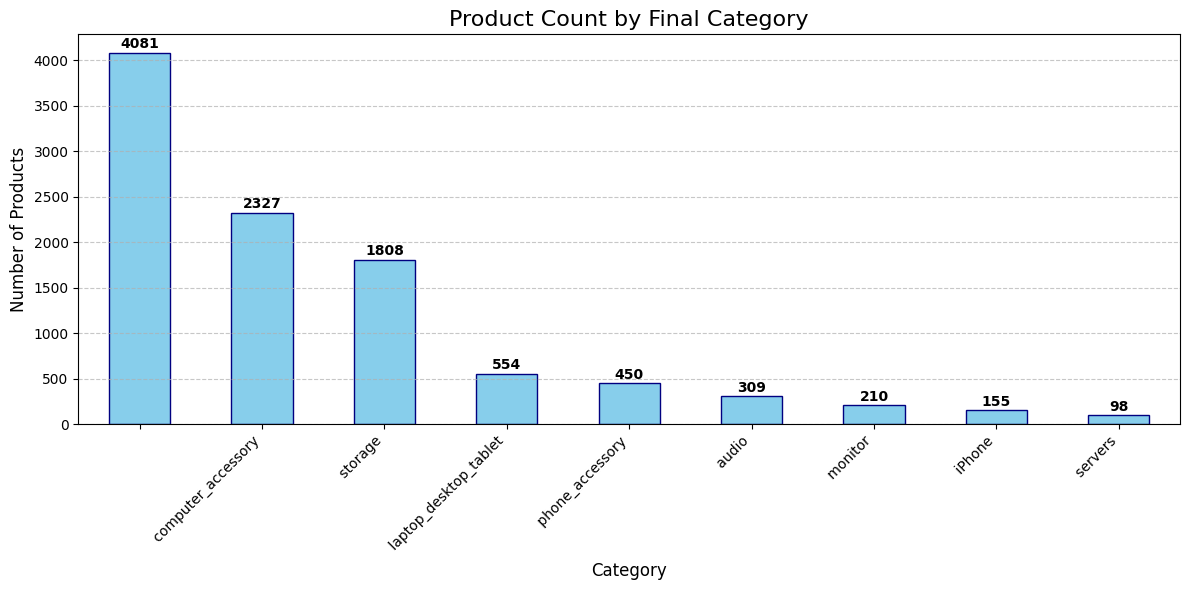

In [164]:
import matplotlib.pyplot as plt

# 1. Calculate counts for each category
category_counts = product_category_ex_df['category'].value_counts()

# 2. Create the plot
plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar', color='skyblue', edgecolor='navy')

# 3. Add styling and labels
plt.title('Product Count by Final Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Add data labels on top of bars
for i, v in enumerate(category_counts):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()